# L4:  Gaussian Process Latent Force Models
### A grey-box architecture that couples physics with data (physics-encoded ML)

---
**file name:** L4_gaussian_process_latent_force_models.ipynb

Part of Lecture 4 - first notebook

**Instructor:** Alice Cicirello

**Generated for Training school scientific machine learning for digital twins**


**The first draft version of the notebook was generated using Anthropic's Claude**

**Date**: September 2026

**Last Modifications and checks made by Alice Cicirello on: 5/09/2026**

---
## Introduction
Many engineering problems have the same awkward shape: **we know the governing equation of
motion, but we do not know the force that drives it.**

* A building shakes — but the wind/earthquake loading is not measured.
* A gearbox rattles — but the internal contact force is inaccessible.
* A biological gene switches on — but the driving protein concentration is hidden.

A pure **physics** model cannot proceed without the input. 
A pure **machine-learning**
model throws away the equation of motion we worked so hard to derive. 

The **Latent Force Model (LFM)** is the grey-box compromise that keeps *both*:

> Put a **Gaussian-process prior** on the unknown force, then push it **through the known
> differential equation**.
>
> Because the equation is a *linear operator*, the result is again
> a Gaussian process — one whose covariance is *shaped by the physics*.

We can then use noisy measurements of the response to infer, with calibrated uncertainty,
**both the hidden force and the full internal state** of the system.

This notebook is self-contained (`numpy`, `scipy`, `matplotlib`, `sklearn`) and builds the
idea from probability first principles up to a working state-space implementation on a
mass–spring–damper.

**Roadmap**

| Part | Topic |
|---|---|
| 1 | Probability fundamentals — the Gaussian and its two magic identities |
| 2 | Gaussian processes in one page |
| 3 | The Latent Force Model idea — a GP through a differential operator |
| 4 | Worked example 1 — recover an unknown force (analytical / dense GP) |
| 5 | The chosen architecture — state-space GP-LFM (Matérn ↔ SDE + Kalman) |
| 6 | Worked example 2 — mass–spring–damper driven by a hidden force |
| 7 | Summary, when-to-use, and references |

*Álvarez, Luengo & Lawrence (2009, 2013); Hartikainen & Särkkä (2011); Särkkä, Solin &
Hartikainen (2013).*


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import cholesky, solve
from scipy.linalg import expm, cho_factor, cho_solve, solve_continuous_lyapunov
from scipy.integrate import solve_ivp

np.random.seed(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Environment ready.")


Environment ready.


## Part 1 — Probability fundamentals (recap from previous notebooks)

Everything in this notebook is built from **one distribution** (the Gaussian) and **two
identities**. Master these and the rest is bookkeeping.

### 1.1 A Gaussian random variable

A continuous random variable $x$ is described by a probability density $p(x)\ge 0$ with
$\int p(x)\,dx = 1$. 

The **Gaussian (normal)** density is

$$
\mathcal{N}(x\mid \mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),
$$

with **mean** $\mu=\mathbb{E}[x]$ and **variance** $\sigma^2=\mathbb{E}[(x-\mu)^2]$.

The **multivariate** Gaussian over a vector $\mathbf{x}\in\mathbb{R}^d$ is

$$
\mathcal{N}(\mathbf{x}\mid \boldsymbol\mu,\boldsymbol\Sigma)=
\frac{1}{(2\pi)^{d/2}|\boldsymbol\Sigma|^{1/2}}
\exp\!\left(-\tfrac12(\mathbf{x}-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu)\right),
$$

where $\boldsymbol\Sigma$ is the symmetric positive-definite **covariance matrix**,
$\Sigma_{ij}=\mathrm{cov}(x_i,x_j)$. Its off-diagonal entries encode how the components
co-vary — this is exactly what a physical model will imprint onto the force later.


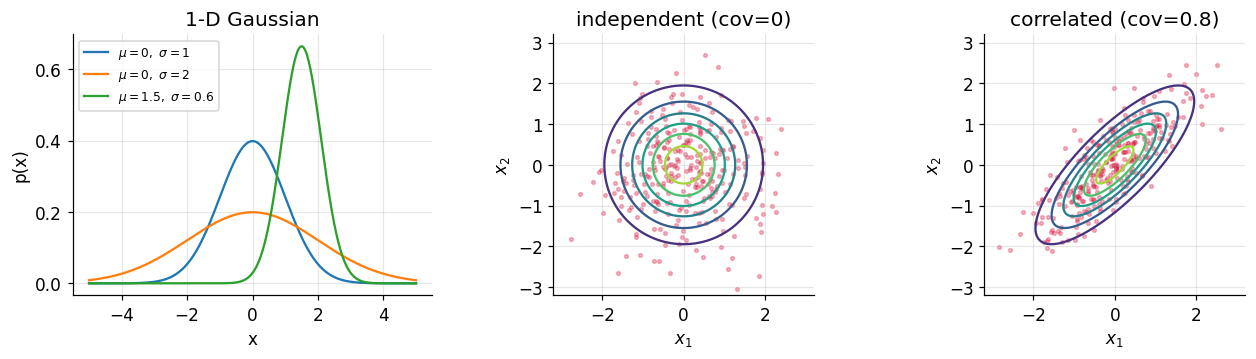

In [2]:
# The Gaussian and how covariance tilts a 2-D distribution
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))

xs = np.linspace(-5, 5, 400)
for mu, s in [(0, 1), (0, 2), (1.5, 0.6)]:
    ax[0].plot(xs, np.exp(-(xs-mu)**2/(2*s**2))/np.sqrt(2*np.pi*s**2),
               label=fr"$\mu={mu},\ \sigma={s}$")
ax[0].set(title="1-D Gaussian", xlabel="x", ylabel="p(x)")
ax[0].legend(fontsize=8)

def gauss2d(Sigma, ax, title):
    g = np.linspace(-3.2, 3.2, 200)
    X, Y = np.meshgrid(g, g)
    P = np.stack([X.ravel(), Y.ravel()])
    Si = np.linalg.inv(Sigma)
    q = np.einsum('ij,ji->i', P.T @ Si, P)
    Z = np.exp(-0.5*q).reshape(X.shape)
    ax.contour(X, Y, Z, levels=6, cmap="viridis")
    L = cholesky(Sigma)
    s = L @ np.random.randn(2, 300)
    ax.scatter(s[0], s[1], s=6, alpha=0.3, color="crimson")
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$")
    ax.set_aspect("equal")

gauss2d(np.array([[1.0, 0.0],[0.0, 1.0]]), ax[1], "independent (cov=0)")
gauss2d(np.array([[1.0, 0.8],[0.8, 1.0]]), ax[2], "correlated (cov=0.8)")
plt.tight_layout(); plt.show()


### 1.2 Joint, marginal, conditional

For two blocks of variables $\mathbf{x}$ and $\mathbf{y}$:

* **Joint** $p(\mathbf{x},\mathbf{y})$ — the full picture.
* **Marginal** $p(\mathbf{x})=\int p(\mathbf{x},\mathbf{y})\,d\mathbf{y}$ — integrate out what you don't care about.
* **Conditional** $p(\mathbf{x}\mid\mathbf{y})=p(\mathbf{x},\mathbf{y})/p(\mathbf{y})$ — what $\mathbf{x}$ becomes *once $\mathbf{y}$ is observed*.

They are tied together by the **sum and product rules**, and their asymmetric form is
**Bayes' theorem**:

$$
\underbrace{p(\mathbf{x}\mid \mathbf{y})}_{\text{posterior}}
=\frac{\overbrace{p(\mathbf{y}\mid \mathbf{x})}^{\text{likelihood}}\,
\overbrace{p(\mathbf{x})}^{\text{prior}}}{\underbrace{p(\mathbf{y})}_{\text{evidence}}}.
$$

Inferring a hidden force from measurements will be *exactly* this operation:
prior (GP on the force) $\times$ likelihood (physics + sensor noise) $\to$ posterior.

### 1.3 The two identities that make everything Gaussian

Write a jointly Gaussian vector in blocks,

$$
\begin{bmatrix}\mathbf{x}\\ \mathbf{y}\end{bmatrix}\sim
\mathcal{N}\!\left(
\begin{bmatrix}\boldsymbol\mu_x\\ \boldsymbol\mu_y\end{bmatrix},
\begin{bmatrix}\mathbf{A} & \mathbf{C}\\ \mathbf{C}^\top & \mathbf{B}\end{bmatrix}
\right).
$$

**(i) Marginalisation** — a marginal of a Gaussian is Gaussian, and you just *read off* the blocks:

$$
\mathbf{x}\sim\mathcal{N}(\boldsymbol\mu_x,\ \mathbf{A}).
$$

**(ii) Conditioning** — a conditional of a Gaussian is Gaussian:

$$
\mathbf{x}\mid\mathbf{y}\sim\mathcal{N}\!\big(
\boldsymbol\mu_x+\mathbf{C}\mathbf{B}^{-1}(\mathbf{y}-\boldsymbol\mu_y),\ \
\mathbf{A}-\mathbf{C}\mathbf{B}^{-1}\mathbf{C}^\top\big).
$$

Observing $\mathbf{y}$ **shifts the mean** toward it and **shrinks the covariance**
(the term $-\mathbf{C}\mathbf{B}^{-1}\mathbf{C}^\top$ is the information $\mathbf{y}$ carried
about $\mathbf{x}$). GP regression, the Kalman filter, and force inference are all this one line.


Before:  x ~ N(0, 1.0)
After observing y=1.3:  x ~ N(1.040, 0.360)


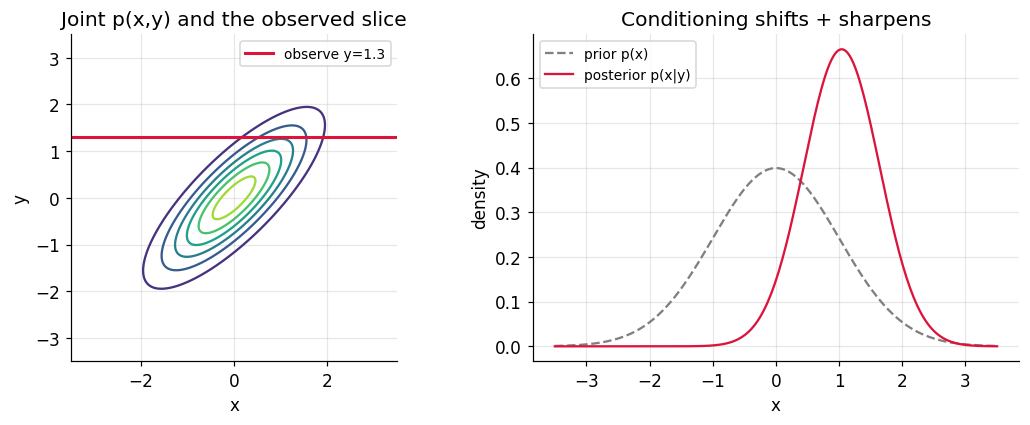

In [3]:
# Conditioning in action: watch a bivariate Gaussian collapse when we observe y
mu = np.array([0.0, 0.0])
A, B, C = 1.0, 1.0, 0.8              # cov = [[A, C],[C, B]]
Sigma = np.array([[A, C],[C, B]])

y_obs = 1.3
mu_cond = mu[0] + C*(1.0/B)*(y_obs - mu[1])
var_cond = A - C*(1.0/B)*C
print(f"Before:  x ~ N(0, {A})")
print(f"After observing y={y_obs}:  x ~ N({mu_cond:.3f}, {var_cond:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
g = np.linspace(-3.5, 3.5, 250)
X, Y = np.meshgrid(g, g)
Si = np.linalg.inv(Sigma)
Z = np.exp(-0.5*(Si[0,0]*X**2 + 2*Si[0,1]*X*Y + Si[1,1]*Y**2))
ax[0].contour(X, Y, Z, levels=6, cmap="viridis")
ax[0].axhline(y_obs, color="crimson", lw=2, label=f"observe y={y_obs}")
ax[0].set(title="Joint p(x,y) and the observed slice", xlabel="x", ylabel="y")
ax[0].legend(fontsize=9); ax[0].set_aspect("equal")

ax[1].plot(g, np.exp(-(g-mu[0])**2/(2*A))/np.sqrt(2*np.pi*A),
           "--", color="grey", label="prior p(x)")
ax[1].plot(g, np.exp(-(g-mu_cond)**2/(2*var_cond))/np.sqrt(2*np.pi*var_cond),
           color="crimson", label="posterior p(x|y)")
ax[1].set(title="Conditioning shifts + sharpens", xlabel="x", ylabel="density")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


### 1.4 The property that powers the LFM: **linearity**

If $\mathbf{x}\sim\mathcal{N}(\boldsymbol\mu,\boldsymbol\Sigma)$ and we apply *any* linear
map $\mathbf{y}=\mathbf{M}\mathbf{x}+\mathbf{b}$, then

$$
\mathbf{y}\sim\mathcal{N}\big(\mathbf{M}\boldsymbol\mu+\mathbf{b},\ \ \mathbf{M}\boldsymbol\Sigma\mathbf{M}^\top\big).
$$

**Gaussians are closed under linear transformation.** 

**A linear differential equation is a linear operator.** 

Hypothesis

the *force* is a Gaussian process

the *equation of motion* is linear

the *response* is Gaussian too — this single fact is the whole reason the Latent
Force Model is analytically tractable!

We verify it numerically below.


In [4]:
# Push a Gaussian through a linear map M; compare empirical vs predicted covariance
M = np.array([[2.0, 0.5],[ -1.0, 1.0]])
Sig = np.array([[1.0, 0.6],[0.6, 1.5]])
L = cholesky(Sig)
samples = (L @ np.random.randn(2, 200000))          # x ~ N(0, Sig)
y = M @ samples                                     # y = M x
emp = np.cov(y)
pred = M @ Sig @ M.T
print("Predicted  M Σ Mᵀ =\n", np.round(pred, 3))
print("Empirical  cov(y) =\n", np.round(emp, 3))
print("max abs difference:", np.abs(pred - emp).max().round(4))


Predicted  M Σ Mᵀ =
 [[ 5.575 -0.35 ]
 [-0.35   1.3  ]]
Empirical  cov(y) =
 [[ 5.558 -0.344]
 [-0.344  1.297]]
max abs difference: 0.0167


## Part 2 — Gaussian processes in one page (recap from previous notebooks)

A **Gaussian process (GP)** is a Gaussian distribution over *functions*. It is defined by a
**mean function** $m(t)$ and a **covariance / kernel function** $k(t,t')$:

$$
f(t)\sim\mathcal{GP}\big(m(t),\,k(t,t')\big).
$$

The defining property: for **any** finite set of inputs $t_1,\dots,t_N$, the function values
$\mathbf{f}=[f(t_1),\dots,f(t_N)]^\top$ are jointly Gaussian,
$\mathbf{f}\sim\mathcal{N}(\mathbf{m},\mathbf{K})$ with $K_{ij}=k(t_i,t_j)$.

A common choice is the **squared-exponential (RBF)** kernel

$$
k(t,t')=\sigma^2\exp\!\left(-\frac{(t-t')^2}{2\ell^2}\right),
$$

with signal variance $\sigma^2$ and length-scale $\ell$ (how fast the function wiggles).

**GP regression.** Given noisy data $y_i=f(t_i)+\varepsilon_i$, $\varepsilon_i\sim\mathcal{N}(0,\sigma_n^2)$,
we predict $f_\*$ at new inputs $T_\*$ by writing the joint Gaussian of data and test points
and applying the **conditioning identity** from §1.3:

$$
\mathbf{f}_\*\mid \mathbf{y}\sim\mathcal{N}(\bar{\mathbf{f}}_\*,\ \mathrm{cov}(\mathbf{f}_\*)),
$$
$$
\bar{\mathbf{f}}_\*=\mathbf{K}_{\*}\big(\mathbf{K}+\sigma_n^2\mathbf{I}\big)^{-1}\mathbf{y},\qquad
\mathrm{cov}(\mathbf{f}_\*)=\mathbf{K}_{\*\*}-\mathbf{K}_{\*}\big(\mathbf{K}+\sigma_n^2\mathbf{I}\big)^{-1}\mathbf{K}_{\*}^\top .
$$

That is *literally* the conditioning formula with $\mathbf{A}=\mathbf{K}_{\*\*}$,
$\mathbf{C}=\mathbf{K}_\*$, $\mathbf{B}=\mathbf{K}+\sigma_n^2\mathbf{I}$. We implement it from
scratch with a Cholesky solve (Rasmussen & Williams, 2006, Alg. 2.1).


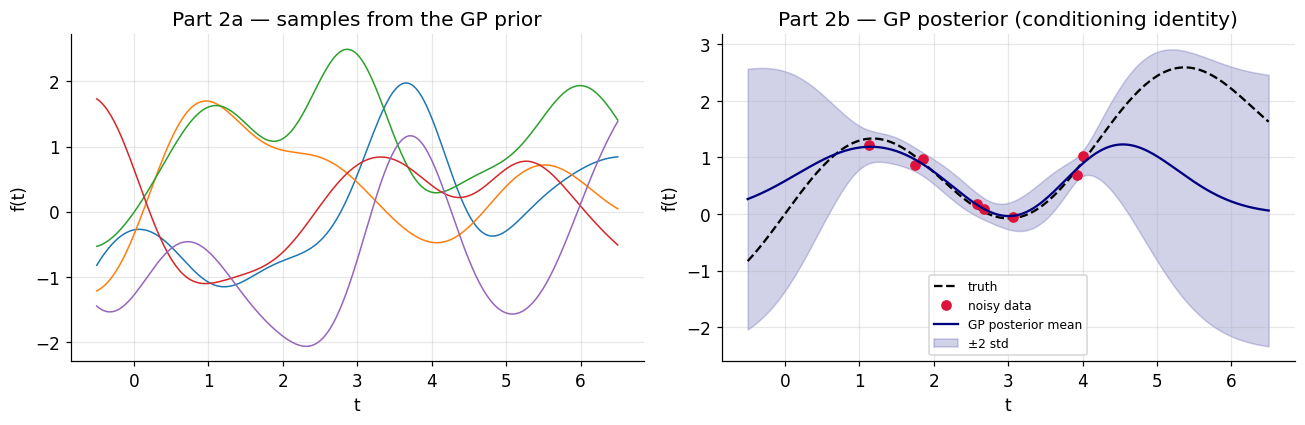

In [5]:
def rbf(a, b, sigma=1.0, ell=1.0):
    d = a.reshape(-1,1) - b.reshape(1,-1)
    return sigma**2 * np.exp(-0.5*(d/ell)**2)

def gp_regression(t_tr, y_tr, t_te, sigma=1.0, ell=1.0, noise=1e-2):
    K   = rbf(t_tr, t_tr, sigma, ell) + noise*np.eye(len(t_tr))
    Ks  = rbf(t_te, t_tr, sigma, ell)
    Kss = rbf(t_te, t_te, sigma, ell)
    Lc  = cho_factor(K, lower=True)
    mean = Ks @ cho_solve(Lc, y_tr)
    v    = cho_solve(Lc, Ks.T)
    cov  = Kss - Ks @ v
    return mean, cov

# toy data from a hidden smooth function
f_true = lambda t: np.sin(1.5*t) + 0.3*t
t_tr = np.sort(np.random.uniform(0, 6, 8))
y_tr = f_true(t_tr) + 0.15*np.random.randn(len(t_tr))
t_te = np.linspace(-0.5, 6.5, 300)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# prior samples
Kpr = rbf(t_te, t_te, 1.0, 0.8) + 1e-8*np.eye(len(t_te))
Lp = cholesky(Kpr)
for _ in range(5):
    ax[0].plot(t_te, Lp @ np.random.randn(len(t_te)), lw=1)
ax[0].set(title="Part 2a — samples from the GP prior", xlabel="t", ylabel="f(t)")

m, C = gp_regression(t_tr, y_tr, t_te, sigma=1.2, ell=0.9, noise=0.15**2)
sd = np.sqrt(np.clip(np.diag(C), 0, None))
ax[1].plot(t_te, f_true(t_te), "k--", label="truth")
ax[1].plot(t_tr, y_tr, "o", color="crimson", label="noisy data")
ax[1].plot(t_te, m, color="navy", label="GP posterior mean")
ax[1].fill_between(t_te, m-2*sd, m+2*sd, color="navy", alpha=0.18, label="±2 std")
ax[1].set(title="Part 2b — GP posterior (conditioning identity)", xlabel="t", ylabel="f(t)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## Part 3 — The Latent Force Model idea

Standard GP regression is **black-box**: 

the kernel encodes only vague beliefs ("smooth",
"periodic"). 

In engineering we usually know *more* — we know the **equation of motion**. 

The
LFM injects that knowledge!

### 3.1 A linear system driven by a latent force

Let the response $y(t)$ obey a **linear differential equation** with a **latent (unobserved)
force** $u(t)$. A first-order example:

$$
\frac{d\,y(t)}{dt} + D\,y(t) = S\,u(t).
$$

A second-order (mechanical) example — a mass–spring–damper — is

$$
m\,\ddot{y}(t)+c\,\dot{y}(t)+k\,y(t)=u(t).
$$

this can be written in the state-space as a set of two first ordder differential equations... but we will takle this in the section 5.

The left-hand side is a **linear operator** $\mathcal{L}$ acting on $y$; we write
$\mathcal{L}\,y = u$. Its inverse is a **convolution** with the system's **Green's function**
(impulse response) $G(t,\tau)$:

$$
y(t)=\int_0^t G(t,\tau)\,u(\tau)\,d\tau .
$$

For the first-order system, $G(t,\tau)=S\,e^{-D(t-\tau)}$ for $t\ge\tau$. This is a **linear
map** from the force $u$ to the response $y$.

### 3.2 GP force in, GP response out

Now place a **GP prior on the latent force**, $u(t)\sim\mathcal{GP}(0,k_{uu}(t,t'))$. Because
$y$ is a *linear* functional of $u$ (§1.4), $y$ is **also a GP**, and we can compute its
covariance by pushing the kernel through the Green's function twice:

$$
k_{yy}(t,t')=\int_0^{t}\!\!\int_0^{t'} G(t,\tau)\,G(t',\tau')\,k_{uu}(\tau,\tau')\,d\tau\,d\tau',
$$

and the crucial **cross-covariance** between response and force,

$$
k_{yu}(t,t')=\int_0^{t} G(t,\tau)\,k_{uu}(\tau,t')\,d\tau .
$$

For an RBF force kernel these integrals have **closed forms** in terms of error functions
(Lawrence, Sanguinetti & Rasmussen, 2007; Álvarez et al., 2009). Here we compute them
**numerically by quadrature** — fully transparent and easy to verify.

**Why the cross-covariance matters.** With $k_{yy}$ and $k_{yu}$ in hand, the joint of
"observed responses" and "unknown force" is Gaussian, so the **conditioning identity of
§1.3 recovers the hidden force from measurements of the response** — with uncertainty bands.
That is a Latent Force Model.


Built covariances: (240, 240) (240, 240) (240, 240)


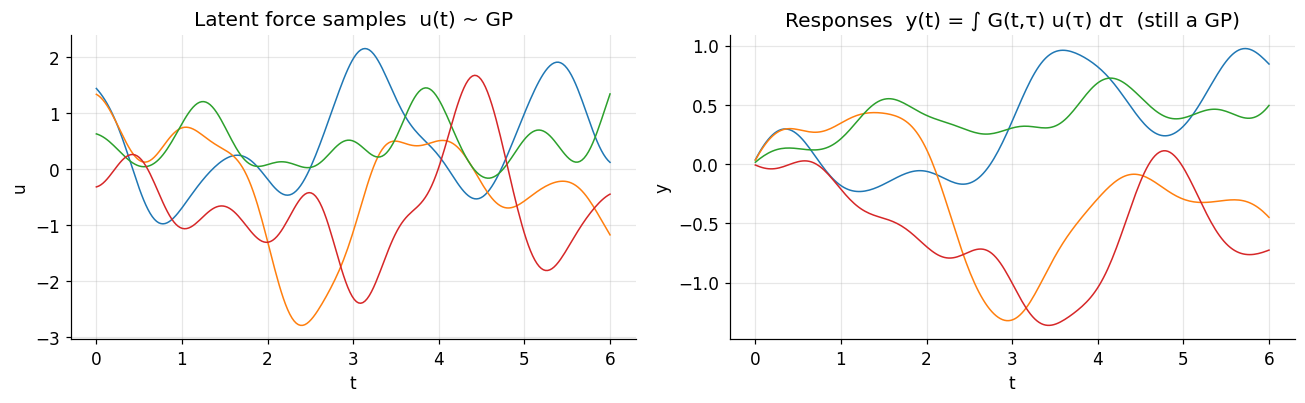

In [6]:
# Build the LFM covariances by quadrature for the 1st-order system  y' + D y = u
D, S = 1.0, 1.0
ell_u, sig_u = 0.4, 1.0                      # RBF force kernel hyper-parameters
t = np.linspace(0, 6, 240)                   # fine quadrature grid
w = np.gradient(t)                           # trapezoid-ish quadrature weights

# causal Green's function G[i,j] = S e^{-D (t_i - t_j)} for t_j <= t_i
dt = t.reshape(-1,1) - t.reshape(1,-1)
G  = np.where(dt >= 0, S*np.exp(-D*dt), 0.0)
GW = G * w.reshape(1,-1)                      # fold quadrature weights in

Kuu = rbf(t, t, sig_u, ell_u)                # force auto-covariance
Kyy = GW @ Kuu @ GW.T                         # response auto-covariance  (double integral)
Kyu = GW @ Kuu                                # response-force cross-covariance
print("Built covariances:", Kuu.shape, Kyy.shape, Kyu.shape)

# Sanity visual: samples of the LATENT force and the RESPONSES they induce
Lu = cholesky(Kuu + 1e-9*np.eye(len(t)))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for _ in range(4):
    us = Lu @ np.random.randn(len(t))
    ys = GW @ us
    ax[0].plot(t, us, lw=1)
    ax[1].plot(t, ys, lw=1)
ax[0].set(title="Latent force samples  u(t) ~ GP", xlabel="t", ylabel="u")
ax[1].set(title="Responses  y(t) = ∫ G(t,τ) u(τ) dτ  (still a GP)", xlabel="t", ylabel="y")
plt.tight_layout(); plt.show()


## Part 4 — Worked example 1: recover an unknown force

**Scenario.** A first-order system is driven by a force we cannot measure. We only record a
handful of **noisy samples of the response** $y$. 

Task: reconstruct the hidden force $u(t)$
over the whole interval, with uncertainty.

**Method.** Stack the observed responses $\mathbf{y}$ and the queried force $\mathbf{u}_\*$
into one Gaussian and condition:

$$
\begin{bmatrix}\mathbf{y}\\ \mathbf{u}_\*\end{bmatrix}\sim
\mathcal{N}\!\left(\mathbf{0},
\begin{bmatrix}\mathbf{K}_{yy}+\sigma_n^2\mathbf{I} & \mathbf{K}_{yu}\\
\mathbf{K}_{yu}^\top & \mathbf{K}_{uu}\end{bmatrix}\right)
\;\Rightarrow\;
\mathbf{u}_\*\mid\mathbf{y}\sim\mathcal{N}(\bar{\mathbf{u}}_\*,\,\boldsymbol\Sigma_{u}),
$$
$$
\bar{\mathbf{u}}_\*=\mathbf{K}_{yu}^\top(\mathbf{K}_{yy}+\sigma_n^2\mathbf{I})^{-1}\mathbf{y},\qquad
\boldsymbol\Sigma_{u}=\mathbf{K}_{uu}-\mathbf{K}_{yu}^\top(\mathbf{K}_{yy}+\sigma_n^2\mathbf{I})^{-1}\mathbf{K}_{yu}.
$$

Note we **never observe the force** — it is inferred purely through the physics-shaped
cross-covariance $\mathbf{K}_{yu}$. This is the payoff of the LFM.


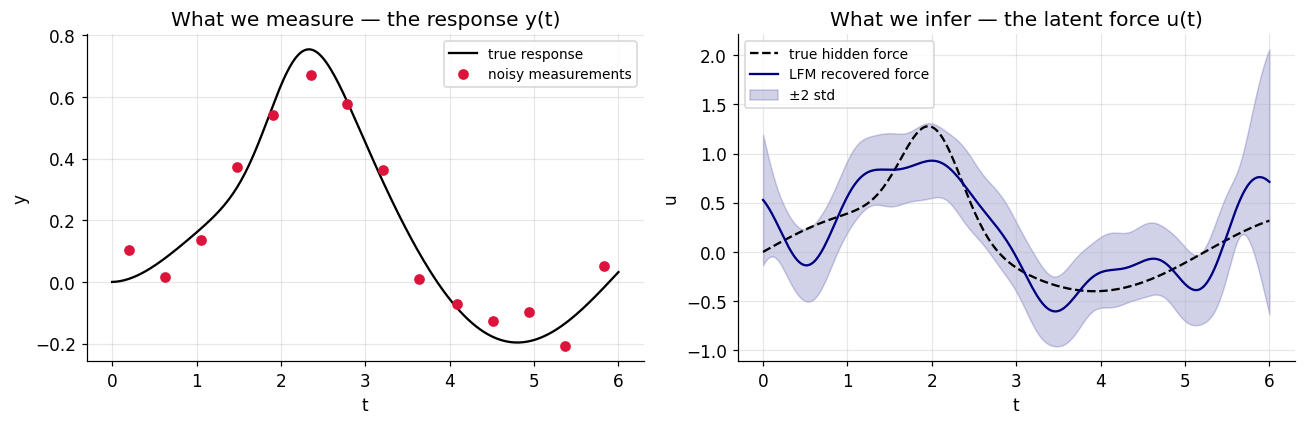

Force reconstruction RMSE = 0.242  (force amplitude ~1)


In [7]:
# A "true" hidden force (deliberately NOT a GP sample: a bump + a slow oscillation)
u_true = np.exp(-((t-2.0)**2)/(2*0.35**2)) + 0.4*np.sin(1.2*t)

# the true response it produces, via the same Green's-function convolution
y_true = GW @ u_true

# observe the response at a few noisy points
noise = 0.05
idx = np.linspace(8, len(t)-8, 14).astype(int)
y_obs = y_true[idx] + noise*np.random.randn(len(idx))

# condition the joint Gaussian: recover u over the whole grid
Kyy_o = Kyy[np.ix_(idx, idx)] + noise**2*np.eye(len(idx))
Kyu_o = Kyu[idx, :]                      # cross-cov between observed y and all u
Lc = cho_factor(Kyy_o, lower=True)
u_mean = Kyu_o.T @ cho_solve(Lc, y_obs)
u_cov  = Kuu - Kyu_o.T @ cho_solve(Lc, Kyu_o)
u_sd   = np.sqrt(np.clip(np.diag(u_cov), 0, None))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, y_true, "k-", label="true response")
ax[0].plot(t[idx], y_obs, "o", color="crimson", label="noisy measurements")
ax[0].set(title="What we measure — the response y(t)", xlabel="t", ylabel="y"); ax[0].legend(fontsize=9)

ax[1].plot(t, u_true, "k--", label="true hidden force")
ax[1].plot(t, u_mean, color="navy", label="LFM recovered force")
ax[1].fill_between(t, u_mean-2*u_sd, u_mean+2*u_sd, color="navy", alpha=0.18, label="±2 std")
ax[1].set(title="What we infer — the latent force u(t)", xlabel="t", ylabel="u"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

rmse = np.sqrt(np.mean((u_mean - u_true)**2))
print(f"Force reconstruction RMSE = {rmse:.3f}  (force amplitude ~1)")


**Read the result.** From only 14 noisy samples of the response, the LFM reconstructs the
hidden force — the bump *and* the slow oscillation — and reports honest error bars that widen
where data is sparse (near the ends). The physics did the heavy lifting: the Green's function
told us how a force at time $\tau$ shows up in the response later, so measurements of $y$ are
informative about $u$.

**But there is a scaling problem.** This "dense-GP" LFM forms and inverts an
$N\times N$ matrix — cost $\mathcal{O}(N^3)$, memory $\mathcal{O}(N^2)$. For a structural
health-monitoring record with $N=10^5$ samples that is hopeless. The next part fixes this.


## Part 5 — The chosen architecture: state-space GP-LFM

### 5.1 Why this architecture

| Requirement (structural dynamics) | Dense GP-LFM (Part 4) | **State-space GP-LFM** |
|---|---|---|
| Long time series ($N\gg 10^4$) | $\mathcal{O}(N^3)$ ✗ | **$\mathcal{O}(N)$** ✓ |
| Streaming / online estimation | batch only ✗ | **recursive (Kalman)** ✓ |
| Recover full internal state (disp, vel, force) | force only | **all states jointly** ✓ |
| Second-order mechanics | messy closed forms | **native (just add rows)** ✓ |

The trick (Hartikainen & Särkkä, 2010, 2011): **rewrite the GP force as the output of a
linear stochastic differential equation (SDE)**, stack it on top of the mechanical
equations, and do inference with the **Kalman filter + RTS smoother** — exact, linear-time
Gaussian inference. This is the standard modern LFM engine and the backbone of the
switching-GPLFM used for friction and joint identification.

### 5.2 A Matérn GP *is* a linear SDE

Many stationary kernels are the steady-state covariance of a linear SDE. The **Matérn-3/2**
kernel

$$
k(\tau)=\sigma^2\Big(1+\tfrac{\sqrt3\,|\tau|}{\ell}\Big)\exp\!\Big(-\tfrac{\sqrt3\,|\tau|}{\ell}\Big)
$$

is generated by the second-order SDE (state $\mathbf{z}=[u,\dot u]^\top$, $\lambda=\sqrt3/\ell$):

$$
d\mathbf{z}=\underbrace{\begin{bmatrix}0&1\\-\lambda^2&-2\lambda\end{bmatrix}}_{\mathbf{F}_u}\mathbf{z}\,dt
+\underbrace{\begin{bmatrix}0\\1\end{bmatrix}}_{\mathbf{L}_u}d\beta,
\qquad
q=\frac{12\sqrt3}{\ell^{3}}\,\sigma^2,
$$

where $\beta$ is Brownian motion with spectral density $q$. The force is
$u(t)=\mathbf{H}_u\mathbf{z}$ with $\mathbf{H}_u=[1,\ 0]$. (Matérn-3/2 gives a
once-differentiable, physically reasonable force. Choosing $\ell$ sets the force's
correlation time.)


In [8]:
# Verify the Matérn-3/2 <-> SDE equivalence: stationary state covariance reproduces the kernel
def matern32_sde(ell, sigma):
    lam = np.sqrt(3.0)/ell
    F = np.array([[0.0, 1.0], [-lam**2, -2*lam]])
    L = np.array([[0.0], [1.0]])
    q = 12*np.sqrt(3.0)/ell**3 * sigma**2
    return F, L, q

ell_test, sig_test = 0.8, 1.0
F, L, q = matern32_sde(ell_test, sig_test)

# stationary covariance solves the Lyapunov equation  F P + P Fᵀ + L q Lᵀ = 0
Pinf = solve_continuous_lyapunov(F, -(L*q) @ L.T)
print("Stationary state covariance P∞ =\n", np.round(Pinf, 4))
print(f"P∞[0,0] should equal σ² = {sig_test**2}   ->  {Pinf[0,0]:.4f}")
print(f"P∞[1,1] should equal 3σ²/ℓ² = {3*sig_test**2/ell_test**2:.4f}  ->  {Pinf[1,1]:.4f}")


Stationary state covariance P∞ =
 [[1.     0.    ]
 [0.     4.6875]]
P∞[0,0] should equal σ² = 1.0   ->  1.0000
P∞[1,1] should equal 3σ²/ℓ² = 4.6875  ->  4.6875


### 5.3 Couple the force SDE to the mechanics

Take the mass–spring–damper $m\ddot y + c\dot y + k y = u$. Its state is
$[y,\dot y]$. Stack it with the force state $[u,\dot u]$ into one **augmented state**
$\mathbf{s}=[\,y,\ \dot y,\ u,\ \dot u\,]^\top$ obeying a single linear SDE
$d\mathbf{s}=\mathbf{F}\mathbf{s}\,dt+\mathbf{L}\,d\beta$:

$$
\mathbf{F}=\begin{bmatrix}
0&1&0&0\\
-k/m&-c/m&1/m&0\\
0&0&0&1\\
0&0&-\lambda^2&-2\lambda
\end{bmatrix},\qquad
\mathbf{L}=\begin{bmatrix}0\\0\\0\\1\end{bmatrix}.
$$

Rows 1–2 are Newton's law (with the force entering $\ddot y$ through $1/m$); rows 3–4 are the
Matérn force generator. Process noise enters **only** the force channel.

**Discretise.** Over a fixed step $\Delta t$ the SDE becomes an exact **linear-Gaussian
state-space model**

$$
\mathbf{s}_{k}=\mathbf{A}\,\mathbf{s}_{k-1}+\mathbf{q}_k,\quad
\mathbf{q}_k\sim\mathcal{N}(\mathbf{0},\mathbf{Q}),\qquad
\mathbf{A}=e^{\mathbf{F}\Delta t},
$$
with $\mathbf{Q}=\int_0^{\Delta t}e^{\mathbf{F}s}\mathbf{L}q\mathbf{L}^\top e^{\mathbf{F}^\top s}ds$
computed exactly by the **Van Loan** matrix-exponential trick. In structural dynamics the
practical sensor is an **accelerometer**, and acceleration is itself a *linear* function of
the augmented state, $\ddot y=(u-c\dot y-ky)/m$:

$$
z_k=\mathbf{H}\mathbf{s}_k+r_k,\quad
\mathbf{H}=\big[\,-k/m,\ -c/m,\ 1/m,\ 0\,\big],\quad r_k\sim\mathcal{N}(0,R).
$$

The accelerometer sees the force *directly* (through $1/m$), which is what makes force
estimation **well-posed**. Recovering a force from *displacement* alone is a much harder,
near-ill-posed inverse — we demonstrate that contrast at the end.

### 5.4 Inference = Kalman filter + RTS smoother

The Kalman filter is *nothing but* the conditioning identity of §1.3 applied recursively in
time, and the RTS smoother sweeps backward to use future data too. Together they return the
**posterior over the entire augmented state** — displacement, velocity **and the latent
force** — in $\mathcal{O}(N)$. (Kalman 1960; Rauch–Tung–Striebel 1965; Särkkä 2013.)


In [9]:
def van_loan(F, L, q, dt):
    '''Exact discrete transition A and process-noise cov Q for dz=Fz dt + L dβ.'''
    n = F.shape[0]
    Qc = (L * q) @ L.T
    M = np.zeros((2*n, 2*n))
    M[:n, :n] = F
    M[:n, n:] = Qc
    M[n:, n:] = -F.T
    E = expm(M * dt)
    A = E[:n, :n]
    Q = E[:n, n:] @ A.T
    Q = 0.5*(Q + Q.T)                    # symmetrise
    return A, Q

def kalman_rts(zs, A, Q, H, R, m0, P0):
    '''Forward Kalman filter + backward RTS smoother. Returns smoothed means & covs.'''
    n = A.shape[0]; N = len(zs)
    mf = np.zeros((N, n)); Pf = np.zeros((N, n, n))
    mp = np.zeros((N, n)); Pp = np.zeros((N, n, n))
    m, P = m0.copy(), P0.copy()
    for k in range(N):
        # predict
        m = A @ m
        P = A @ P @ A.T + Q
        mp[k], Pp[k] = m, P
        # update (conditioning identity, §1.3)
        S = H @ P @ H.T + R
        K = (P @ H.T) / S
        m = m + (K * (zs[k] - H @ m)).ravel()
        P = P - np.outer(K, H @ P)
        P = 0.5*(P + P.T)
        mf[k], Pf[k] = m, P
    # RTS backward smoother
    ms = mf.copy(); Ps = Pf.copy()
    for k in range(N-2, -1, -1):
        C = Pf[k] @ A.T @ np.linalg.inv(Pp[k+1])
        ms[k] = mf[k] + C @ (ms[k+1] - mp[k+1])
        Ps[k] = Pf[k] + C @ (Ps[k+1] - Pp[k+1]) @ C.T
    return ms, Ps

print("Kalman filter + RTS smoother and Van Loan discretisation ready.")


Kalman filter + RTS smoother and Van Loan discretisation ready.


## Part 6 — Worked example 2: a shaken mass–spring–damper

**Scenario.** A single-degree-of-freedom oscillator (think one floor of a structure) is hit
by an **unknown transient force** — an impulsive event followed by a decaying wobble. We
mount **one accelerometer**, sampled at 50 Hz with noise. We know $m,c,k$ from a modal test.
Recover the **force history**, the unmeasured **velocity**, and the **displacement**.

We first simulate the ground truth by integrating the ODE with the true force, then hand only
the noisy acceleration to the state-space GP-LFM.


In [10]:
# ---- true system and true (unknown-to-the-estimator) force -----------------
m_, c_, k_ = 1.0, 0.6, 40.0                 # mass, damping, stiffness
wn = np.sqrt(k_/m_); zeta = c_/(2*np.sqrt(k_*m_))
print(f"Natural freq = {wn/2/np.pi:.2f} Hz,  damping ratio = {zeta:.3f}")

def true_force(t):
    # an impulsive burst near t=0.6 s plus a slow decaying oscillation
    burst = 6.0*np.exp(-((t-0.6)**2)/(2*0.08**2))
    wobble = 1.5*np.exp(-0.5*t)*np.sin(2*np.pi*1.0*t)
    return burst + wobble

def rhs(t, s):
    y, v = s
    return [v, (true_force(t) - c_*v - k_*y)/m_]

fs = 50.0; T = 6.0
t_grid = np.arange(0, T, 1/fs)
sol = solve_ivp(rhs, [0, T], [0.0, 0.0], t_eval=t_grid, rtol=1e-9, atol=1e-12)
y_true = sol.y[0]; v_true = sol.y[1]; f_true_series = true_force(t_grid)
a_true = (f_true_series - c_*v_true - k_*y_true)/m_       # true acceleration

# one noisy accelerometer (absolute noise std ~0.03, i.e. ~1% of the peak response)
R_meas = (0.03)**2
z_meas = a_true + np.sqrt(R_meas)*np.random.randn(len(t_grid))
print("Simulated", len(t_grid), "samples of noisy acceleration.")


Natural freq = 1.01 Hz,  damping ratio = 0.047
Simulated 300 samples of noisy acceleration.


Simulated 300 samples of noisy acceleration.


In [11]:
# ---- build the augmented state-space GP-LFM --------------------------------
ell_f, sig_f = 0.10, 5.0                     # force GP: correlation time & amplitude scale
lam = np.sqrt(3.0)/ell_f
q_f = 12*np.sqrt(3.0)/ell_f**3 * sig_f**2

F = np.array([
    [0.0,      1.0,     0.0,      0.0],
    [-k_/m_,  -c_/m_,   1.0/m_,   0.0],
    [0.0,      0.0,     0.0,      1.0],
    [0.0,      0.0,    -lam**2,  -2*lam],
])
L = np.array([[0.0],[0.0],[0.0],[1.0]])
H = np.array([[-k_/m_, -c_/m_, 1.0/m_, 0.0]])   # observe acceleration (accelerometer)

dt = 1/fs
A, Q = van_loan(F, L, q_f, dt)

# prior: physical states near zero; force states at Matérn stationary covariance
Pinf_f = solve_continuous_lyapunov(np.array([[0,1.0],[-lam**2,-2*lam]]),
                                   -(np.array([[0.0],[1.0]])*q_f) @ np.array([[0.0,1.0]]))
m0 = np.zeros(4)
P0 = np.diag([1e-4, 1e-2, Pinf_f[0,0], Pinf_f[1,1]])

ms, Ps = kalman_rts(z_meas, A, Q, H, R_meas, m0, P0)
sd = np.sqrt(np.clip(np.diagonal(Ps, axis1=1, axis2=2), 0, None))
print("Inference done. Recovered states shape:", ms.shape)


Inference done. Recovered states shape: (300, 4)


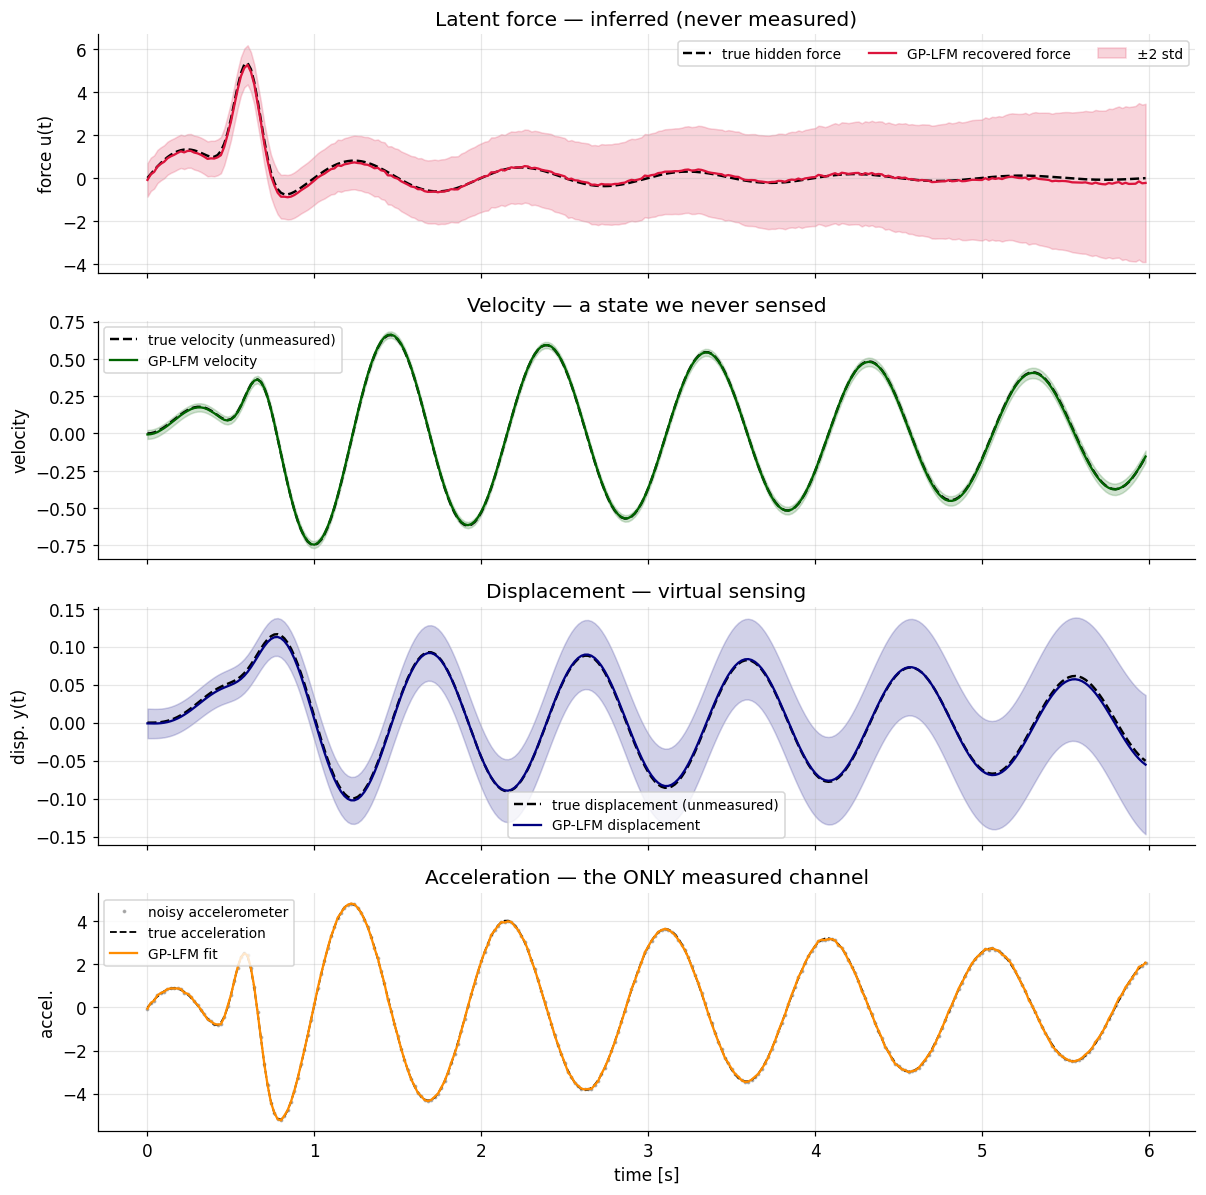

Force  NMSE = 1.23 %   (force is never measured)
Vel.   NMSE = 0.01 %
Disp.  NMSE = 0.17 %


In [12]:
# ---- results: force, velocity, displacement, acceleration ------------------
fig, ax = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

ax[0].plot(t_grid, f_true_series, "k--", lw=1.6, label="true hidden force")
ax[0].plot(t_grid, ms[:,2], color="crimson", label="GP-LFM recovered force")
ax[0].fill_between(t_grid, ms[:,2]-2*sd[:,2], ms[:,2]+2*sd[:,2],
                   color="crimson", alpha=0.18, label="±2 std")
ax[0].set(ylabel="force u(t)", title="Latent force — inferred (never measured)")
ax[0].legend(fontsize=9, ncol=3)

ax[1].plot(t_grid, v_true, "k--", lw=1.6, label="true velocity (unmeasured)")
ax[1].plot(t_grid, ms[:,1], color="darkgreen", label="GP-LFM velocity")
ax[1].fill_between(t_grid, ms[:,1]-2*sd[:,1], ms[:,1]+2*sd[:,1],
                   color="darkgreen", alpha=0.18)
ax[1].set(ylabel="velocity", title="Velocity — a state we never sensed"); ax[1].legend(fontsize=9)

ax[2].plot(t_grid, y_true, "k--", lw=1.6, label="true displacement (unmeasured)")
ax[2].plot(t_grid, ms[:,0], color="navy", label="GP-LFM displacement")
ax[2].fill_between(t_grid, ms[:,0]-2*sd[:,0], ms[:,0]+2*sd[:,0],
                   color="navy", alpha=0.18)
ax[2].set(ylabel="disp. y(t)", title="Displacement — virtual sensing"); ax[2].legend(fontsize=9)

ax[3].plot(t_grid, z_meas, ".", ms=3, color="grey", alpha=0.55, label="noisy accelerometer")
ax[3].plot(t_grid, a_true, "k--", lw=1.2, label="true acceleration")
ax[3].plot(t_grid, (H @ ms.T).ravel(), color="darkorange", label="GP-LFM fit")
ax[3].set(xlabel="time [s]", ylabel="accel.", title="Acceleration — the ONLY measured channel")
ax[3].legend(fontsize=9)
plt.tight_layout(); plt.show()

# error metrics
def nmse(a, b): return 100*np.mean((a-b)**2)/np.var(b)
print(f"Force  NMSE = {nmse(ms[:,2], f_true_series):.2f} %   (force is never measured)")
print(f"Vel.   NMSE = {nmse(ms[:,1], v_true):.2f} %")
print(f"Disp.  NMSE = {nmse(ms[:,0], y_true):.2f} %")


**Read the result.** With a single noisy accelerometer and the known equation of motion, the
state-space GP-LFM reconstructs, in one $\mathcal{O}(N)$ Kalman/RTS sweep:

* the **hidden force** — the impulsive burst *and* the slow wobble — with tight error bars (NMSE ≈ 1–2 %);
* the **velocity** and **displacement**, which *no sensor ever measured* — recovered through the model (**virtual sensing**);
* a denoised fit of the measured acceleration.

This is the payoff of embedding physics in the prior: a single sensor plus the equation of
motion yields the full state *and* the unknown input. The same computation would be
prohibitive with the dense GP of Part 4. It is precisely the architecture used for
input/force estimation, virtual sensing, and (with a switching extension) friction and joint
identification in structural dynamics.

### 6.1 Things to try
* **The ill-posed inverse.** Switch the sensor to *displacement*, $\mathbf{H}=[1,0,0,0]$, and re-run. Velocity and displacement stay excellent, but **force recovery collapses** — displacement is two integrations removed from the force, so it carries little information about it. Acceleration is the right channel for force estimation.
* **Force smoothness.** Shrink `ell_f` to track sharper forces (at the cost of noisier estimates); grow it to over-smooth. This is the classic bias/variance knob, set by the force's correlation time.
* **Hyper-parameters.** In practice $\ell_f,\sigma_f,R$ are learned by maximising the Kalman filter's **log marginal likelihood** (the sum of one-step predictive densities) — the state-space analogue of the GP evidence in the GP-intro notebook.


## Part 7 — Summary, when to use it, and references

### The architecture in one paragraph
A **Gaussian Process Latent Force Model** places a GP prior on an unmeasured input and pushes
it through a **known linear differential equation**. Because linear operators preserve
Gaussianity, the joint of force and response is a structured GP whose covariance is *shaped by
the physics*. Inference is the Gaussian **conditioning identity**: it recovers the hidden
force and the full state from sparse noisy measurements, with calibrated uncertainty. For long
records the GP is rewritten as a **linear SDE**, stacked onto the equations of motion, and
solved in linear time with the **Kalman filter + RTS smoother**.

### Two equivalent implementations

| | Dense / kernel GP-LFM (Part 4) | State-space GP-LFM (Parts 5–6) |
|---|---|---|
| Inference | batch conditioning of one big Gaussian | recursive Kalman + RTS |
| Cost | $\mathcal{O}(N^3)$ time, $\mathcal{O}(N^2)$ memory | $\mathcal{O}(N)$ time & memory |
| Best for | short records, arbitrary input locations | long/streaming time series, real-time |
| Kernels | any (RBF, Matérn, periodic, …) | Markovian kernels (Matérn, and sums/products) |

### When to reach for a GP-LFM
* You **know the linear dynamics** but the **input is unmeasured** (force/input estimation, virtual sensing).
* You want **uncertainty**, not just a point estimate.
* You need to **fuse physics and data** without discarding either.
* *Extensions:* non-linear or switching dynamics [12] → **switching GP-LFM** (regime-dependent forces, e.g. stick–slip friction); multiple outputs → convolution processes / multi-output GPs.
* Virtual sensing [13],[14]

### References
1. M. Álvarez, D. Luengo, N. D. Lawrence. *Latent Force Models.* AISTATS, 2009.
2. M. Álvarez, D. Luengo, N. D. Lawrence. *Linear Latent Force Models using Gaussian Processes.* IEEE TPAMI 35(11):2693–2705, 2013.
3. N. D. Lawrence, G. Sanguinetti, M. Rasmussen. *Modelling transcriptional regulation using Gaussian processes.* NeurIPS, 2007. *(closed-form first-order LFM covariances)*
4. J. Hartikainen, S. Särkkä. *Sequential inference for latent force models.* UAI, 2011. *(the state-space GP-LFM used here)*
5. J. Hartikainen, S. Särkkä. *Kalman filtering and smoothing solutions to temporal Gaussian process regression models.* MLSP, 2010. *(Matérn ↔ SDE)*
6. S. Särkkä, A. Solin, J. Hartikainen. *Spatiotemporal learning via infinite-dimensional Bayesian filtering and smoothing.* IEEE Signal Processing Magazine 30(4):51–61, 2013.
7. C. E. Rasmussen, C. K. I. Williams. *Gaussian Processes for Machine Learning.* MIT Press, 2006. *(GP regression, kernels; Ch. 2)*
8. S. Särkkä. *Bayesian Filtering and Smoothing.* Cambridge University Press, 2013. *(Kalman/RTS)*
9. R. E. Kalman. *A new approach to linear filtering and prediction problems.* J. Basic Eng. 82(1):35–45, 1960.
10. H. E. Rauch, F. Tung, C. T. Striebel. *Maximum likelihood estimates of linear dynamic systems.* AIAA J. 3(8):1445–1450, 1965.
11. T. J. Rogers, K. Worden, E. J. Cross. *On the application of Gaussian process latent force models for joint input–state–parameter estimation.* MSSP 140:106580, 2020. *(GP-LFM in structural dynamics)*
12. L. Marino, A. Cicirello. *A switching Gaussian process latent force model for the identification of mechanical systems with a discontinuous nonlinearity.* Data-Centric Engineering 4:e18, 2023. *(switching GP-LFM, friction)*
13. Zou J., Lourens E., Cicirello A., Virtual sensing of subsoil strain response in monopile-based offshore wind turbines via Gaussian process latent force models,  Mechanical System and Signal Processing, 2023.
14. Sibille L., Nord T. S. , Cicirello A., Digital twin for virtual sensing of ferry quays via a Gaussian Process Latent Force Model.  Data-Centric Engineering, 2026.
---
*Self-contained teaching notebook — `numpy`, `scipy`, `matplotlib`, `sklearn` only.